# Reaction Barrier Subsets

,wB97M-V,MACE-POLAR-1-S,MACE-POLAR-1-M,MACE-POLAR-1-L,MACE-OMOL-0-100M,MACE-OMOL-0-4M,MACE-MP-0b3
Reaction Subset,,,,,,,
Barrier Heights,1.467,8.374,2.570,2.052,2.260,4.226,16.763
Proton Transfer,1.349,11.249,3.141,2.209,2.366,3.470,17.588
General Reaction Energies,0.984,8.716,1.567,1.717,7.591,9.453,15.185


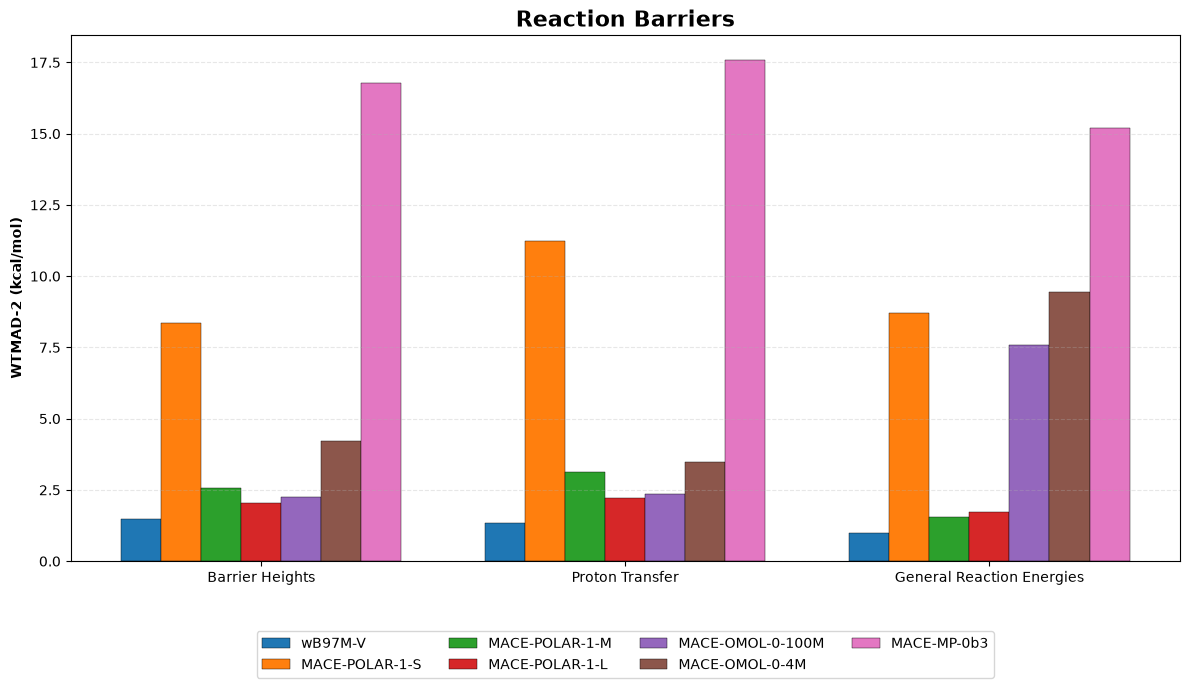

In [1]:
# WTMAD-2 — Reaction Barriers: Barrier Heights, Proton Transfer, General Reaction Energies

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------- Files ----------
BH_FILE = Path("Barrier Height Datatype_MAE Results_MACE models.csv")
TC_FILE = Path("Thermochemistry Datatype_MAE Results_MACE models.csv")

bh = pd.read_csv(BH_FILE).set_index("Dataset")
tc = pd.read_csv(TC_FILE).set_index("Dataset")

# Make model names identical between the two files
rename = {
    "mace-polar-1-s": "MACE-POLAR-1-S",
    "mace-polar-1-m": "MACE-POLAR-1-M",
    "mace-polar-1-l": "MACE-POLAR-1-L",
    "MACE-MP-0b3-medium": "MACE-MP-0b3"
}
bh, tc = bh.rename(columns=rename), tc.rename(columns=rename)

MODELS = [
    "wB97M-V",
    "MACE-POLAR-1-S",
    "MACE-POLAR-1-M",
    "MACE-POLAR-1-L",
    "MACE-OMOL-0-100M",
    "MACE-OMOL-0-4M",
    "MACE-MP-0b3"
]

# ---------- Fig. 2(b) reaction subsets ----------
GROUPS = {
    "Barrier Heights":
        ["BH28", "BH46", "BH876", "BHDIV7", "ORBH35", "CRBH14"],

    "Proton Transfer":
        ["DBH22", "PX9", "WCPT26"],

    "General Reaction Energies":
        ["FH51", "G2RC24", "BH76RC", "CR20", "DARC", "NBPRC", "RC21"]
}

SOURCE = {
    "Barrier Heights": bh,
    "Proton Transfer": bh,
    "General Reaction Energies": tc
}

# <|Eref|> in kcal/mol used for WTMAD-2 weighting
E_SCALE = {
    "BH28": 30.46298824176513,
    "BH46": 17.432621861752537,
    "BH876": 20.37,
    "BHDIV7": 40.05003029573378,
    "ORBH35": 23.886218124293524,
    "CRBH14": 45.525310738872705,

    "DBH22": 21.3445445962571,
    "PX9": 36.600027780445494,
    "WCPT26": 29.16697189652592,

    "FH51": 31.01,
    "G2RC24": 48.8529532795375,
    "BH76RC": 21.39,
    "CR20": 19.31,
    "DARC": 32.47,
    "NBPRC": 27.71,
    "RC21": 35.70
}

# ---------- WTMAD-2 ----------
def wt_mad2(group):
    sets = GROUPS[group]
    mae = SOURCE[group].loc[sets, MODELS]
    w = pd.Series({d: 56.84 / E_SCALE[d] for d in sets})
    return mae.mul(w, axis=0).sum() / w.sum()

WTMAD2 = pd.DataFrame(
    {group: wt_mad2(group) for group in GROUPS}
).T

WTMAD2.index.name = "Reaction Subset"
WTMAD2.to_csv("Reaction_Barriers_WTMAD2_MACE_models.csv")

display(WTMAD2.round(3))

# ---------- Fig. 2(b)-style grouped bar plot ----------
x = np.arange(len(WTMAD2))
width = 0.11

fig, ax = plt.subplots(figsize=(12, 7))

for i, model in enumerate(MODELS):
    ax.bar(
        x + (i - (len(MODELS)-1)/2) * width,
        WTMAD2[model],
        width,
        label=model,
        edgecolor="black",
        linewidth=0.3
    )

ax.set_xticks(x)
ax.set_xticklabels(WTMAD2.index)
ax.set_ylabel("WTMAD-2 (kcal/mol)", fontweight="bold")
ax.set_title("Reaction Barriers", fontweight="bold", fontsize=16)
ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.legend(ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.12))
plt.tight_layout()
plt.savefig("Reaction_Barriers_WTMAD2_Fig2b.png", dpi=300, bbox_inches="tight")
plt.show()

# Thermochemistry Subsets

,wB97M-V,MACE-POLAR-1-S,MACE-POLAR-1-M,MACE-POLAR-1-L,MACE-OMOL-0-100M,MACE-OMOL-0-4M,MACE-MP-0b3
Thermochemistry Subset,,,,,,,
Ionization Potentials,3.718,20.710,26.369,19.816,140.640,117.286,276.662
Electron Affinities,1.703,14.319,9.412,9.170,11.197,12.501,37.009
Proton Affinities,1.503,4.047,2.342,2.109,29.575,40.584,110.069
Mindless Molecules\n(MB08/16),6.120,16.270,14.384,9.862,8.666,16.306,82.079
Bond Dissociation\nEnergies,1.911,8.777,2.877,4.340,5.562,10.130,15.447
Radical Stabilization,0.787,1.335,0.807,0.632,4.970,4.521,8.099


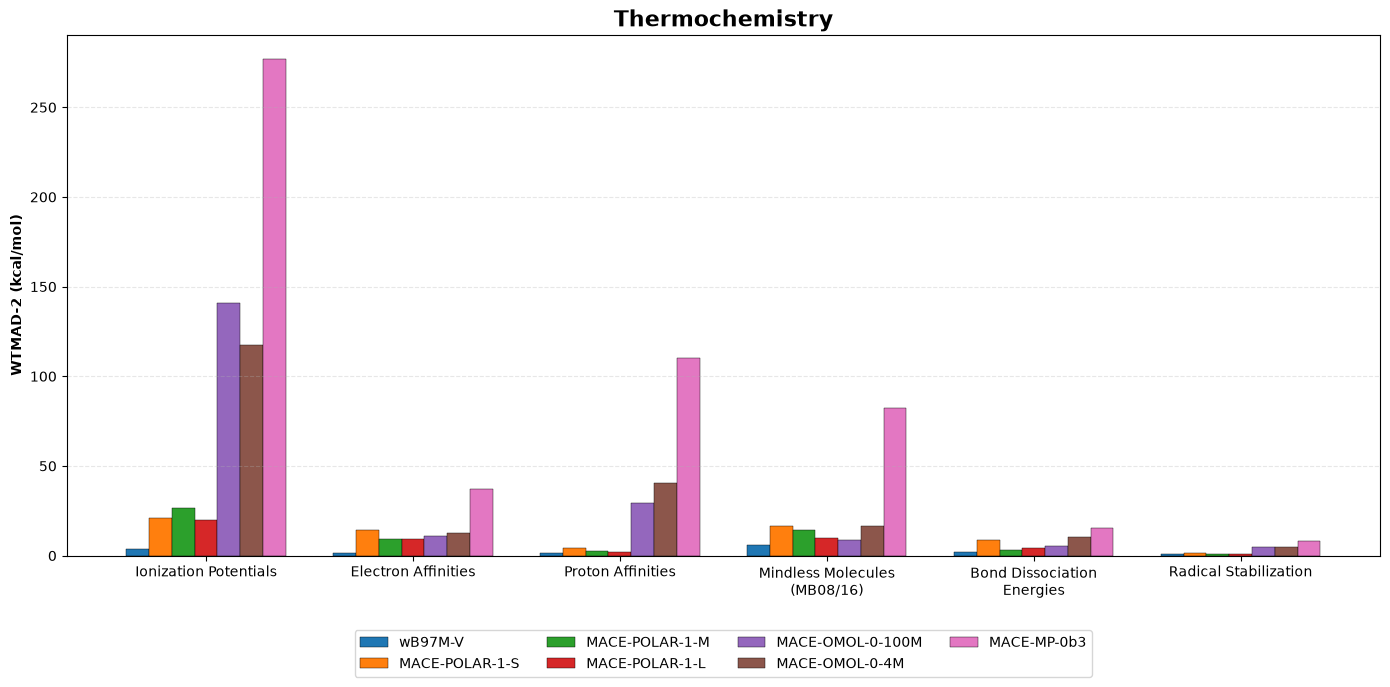

In [3]:
# Thermochemistry WTMAD-2 + Fig. 2(a)-style plot

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

H2K = 627.50947406

ROOT = Path.cwd().parent if Path.cwd().name == "Analysis" else Path.cwd()
I = ROOT/"Info"

MAE_FILE = ROOT/"Thermochemistry Datatype_MAE Results_MACE models.csv"
if not MAE_FILE.exists():
    MAE_FILE = ROOT/"Analysis"/"Thermochemistry Datatype_MAE Results_MACE models.csv"

# ---------- MAE results ----------
df = pd.read_csv(MAE_FILE).set_index("Dataset").rename(columns={
    "mace-polar-1-s": "MACE-POLAR-1-S",
    "mace-polar-1-m": "MACE-POLAR-1-M",
    "mace-polar-1-l": "MACE-POLAR-1-L",
    "MACE-MP-0b3-medium": "MACE-MP-0b3"
})

MODELS = [
    "wB97M-V",
    "MACE-POLAR-1-S",
    "MACE-POLAR-1-M",
    "MACE-POLAR-1-L",
    "MACE-OMOL-0-100M",
    "MACE-OMOL-0-4M",
    "MACE-MP-0b3"
]

# ---------- Fig. 2(a) groups ----------
GROUPS = {
    "Ionization Potentials":
        ["G21IP", "IP23", "IP30"],

    "Electron Affinities":
        ["G21EA", "EA50"],

    "Proton Affinities":
        ["PA26"],

    "Mindless Molecules\n(MB08/16)":
        ["MB08-165", "MB16-43"],

    "Bond Dissociation\nEnergies":
        ["BDE99MR", "BDE99nonMR", "HNBrBDE18", "YBDE18",
         "HAT707MR", "HAT707nonMR", "BSR36"],

    "Radical Stabilization":
        ["RSE43"]
}

# ---------- characteristic reference-energy scale ----------
ev = pd.read_csv(I/"DatasetEval.csv")

all_sets = sum(GROUPS.values(), [])

E_SCALE = (
    ev[ev["Dataset"].isin(all_sets)]
    .assign(Reference_kcal=lambda x: x["Reference"] * H2K)
    .groupby("Dataset")["Reference_kcal"]
    .apply(lambda x: x.abs().mean())
)

# ---------- WTMAD-2 ----------
def wtmad2(sets):
    w = 56.84 / E_SCALE.loc[sets]
    x = df.loc[sets, MODELS]

    numerator   = x.mul(w, axis=0).sum()
    denominator = x.notna().mul(w, axis=0).sum()

    return numerator / denominator

out = pd.DataFrame({
    group: wtmad2(sets)
    for group, sets in GROUPS.items()
}).T

out.index.name = "Thermochemistry Subset"

# ---------- save ----------
out.to_csv(ROOT/"Thermochemistry_WTMAD2_MACE_models.csv")

display(out.round(3))

# ---------- Fig. 2(a)-style grouped bars ----------
x = np.arange(len(out))
width = 0.11

fig, ax = plt.subplots(figsize=(14, 7))

for i, model in enumerate(MODELS):
    ax.bar(
        x + (i-(len(MODELS)-1)/2)*width,
        out[model],
        width,
        label=model,
        edgecolor="black",
        linewidth=.3
    )

ax.set_xticks(x)
ax.set_xticklabels(out.index)
ax.set_ylabel("WTMAD-2 (kcal/mol)", fontweight="bold")
ax.set_title("Thermochemistry", fontsize=16, fontweight="bold")
ax.grid(axis="y", linestyle="--", alpha=.3)
ax.legend(ncol=4, loc="upper center", bbox_to_anchor=(.5, -.13))

plt.tight_layout()
plt.savefig(
    ROOT/"Thermochemistry_WTMAD2_Fig2a.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()